## Problem Definition

### What variable are we predicting?
- We are predicting customer churn means will this customer stop using companies product or services.

### Why is churn prediction important for companies?
- High churn rates signal potential issues with product quality, pricing, customer service, or competition, and can negatively impact revenue and long-term sustainability.

### Is this a classification or regression problem?
- This problem is classification supervised learning as our target variable is distinct not continues and which is 1 (positive or customer leaves) and 0 (negative or customer stays)

## Data Loading

### Converting .xlsx to .csv

- To support all devices and to prevent future complications that might occur we are converting dataset to csv format.

In [1]:
# import pandas as pd

# pd.read_excel("../data/Telco_customer_churn.xlsx").to_csv("../data/Telco_customer_churn.csv", index=False)


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Telco_customer_churn.csv")

print((df.head().to_string()))

   CustomerID  Count        Country       State         City  Zip Code                Lat Long   Latitude   Longitude  Gender Senior Citizen Partner Dependents  Tenure Months Phone Service Multiple Lines Internet Service Online Security Online Backup Device Protection Tech Support Streaming TV Streaming Movies        Contract Paperless Billing             Payment Method  Monthly Charges Total Charges Churn Label  Churn Value  Churn Score  CLTV                   Churn Reason
0  3668-QPYBK      1  United States  California  Los Angeles     90003  33.964131, -118.272783  33.964131 -118.272783    Male             No      No         No              2           Yes             No              DSL             Yes           Yes                No           No           No               No  Month-to-month               Yes               Mailed check            53.85        108.15         Yes            1           86  3239   Competitor made better offer
1  9237-HQITU      1  United States  Calif

## Data Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## Target Distribution

<Axes: xlabel='Churn Value', ylabel='Count'>

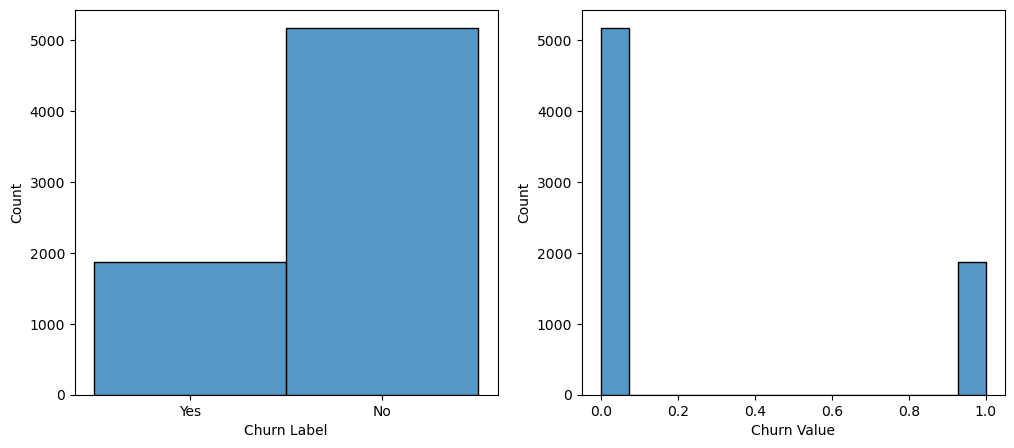

In [5]:
# %matplotlib qt

import matplotlib.pyplot as plt
import seaborn as sns

figure, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(df["Churn Label"], ax=axes[0])

sns.histplot(df["Churn Value"], ax=axes[1])

In [6]:
df["Churn Value"].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

- Ratio of "Customer Stayed" to "Customer Leaved" is approx. 3:1 .
- As you can see target is imbalanced so will definitely have to deal with it while making model.

## Data Cleaning & Sanity Check

In [7]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

### Duplicate Values

In [8]:
df.duplicated().value_counts()

False    7043
Name: count, dtype: int64

- Their are no duplicates in the dataset.

### Identify Target Variable

#### Which column is the actual target?
- Our target is churn but their are many churn related targets and from which this `Churn Label` and `Churn Value` represents churn but we will select `Churn Value` as it is already binary coded 1 (positive or customer leaves) and 0 (negative or customer stays).

#### Are the others derived from the target?
- Yes `Churn Score` and `CLTV` are derived from `Churn Value` our target.

### Detect Leakage Features

- `Churn Value`, `Churn Label`, `Churn Score`, `Churn Reason` and `CLTV` this five columns reveals information related to customer churn from which we have already removed `Churn Reason` and we have selected `Churn Value` as our target so we will remove all others to prevent data leakage.

In [9]:
df.drop(["Churn Label", "Churn Score", "CLTV", "Churn Reason"], axis=1, inplace=True)

### Remove Non-Informative Features

In [10]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


#### Count

In [11]:
df["Count"].value_counts()

Count
1    7043
Name: count, dtype: int64

- Since `Count` has same vales for all the customers it is useless so we will remove it.

In [12]:
df.drop("Count", axis=1, inplace=True)

#### CustomerID

In [13]:
df["CustomerID"].is_unique

True

- Since `CustomerID` does not contribute to prediction of churn as it is unique for every customer and it does not depends on customers behavior and is rather given by company to uniquely identify customers we will remove it.

In [14]:
df.drop("CustomerID", axis=1, inplace=True)

#### Geographical Features

- Since we do not charge customer differently according to location and we do not have any kind of service related change according to area so geological feature are useless for now. But if we change things in the future this then it we may need to include those to so we will remove them for now.

In [15]:
df.drop(["Country", "State", "City", "Zip Code", "Lat Long", "Latitude", "Longitude"], axis=1, inplace=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

### Data Type Correction

In [17]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [18]:
df["Total Charges"].isnull().sum()

np.int64(11)

- Since, Their are less number of nulls we will drop this rows because if we replace it with Zero or mean it might mislead model so it is better to drop them.

In [19]:
df.dropna(inplace=True)

## Baseline Model

In [20]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [21]:
categorical_features = X.select_dtypes(exclude=[np.number]).columns
numerical_features = X.select_dtypes(include=[np.number]).columns

In [22]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

y_test.value_counts(normalize=True), y_train.value_counts(normalize=True)

(Churn Value
 0    0.734186
 1    0.265814
 Name: proportion, dtype: float64,
 Churn Value
 0    0.734222
 1    0.265778
 Name: proportion, dtype: float64)

- As dataset is imbalanced we are stratifying to keep the ratio of imbalance equal in train and test set.

### Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features)
    ]
)

In [24]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(random_state=42))
    ]
)

baseline_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

- We choose logistic regression because it is very simple model and we get to check how linear features are so that we can try different linear models but in this case features are not linear as recall and precision of positive class tells.

In [25]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = baseline_model.predict(x_test)
y_prob = baseline_model.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC: ",roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC:  0.8430548581308789
[[907 126]
 [149 225]]


Text(0.5, 1.0, 'Probability Distribution')

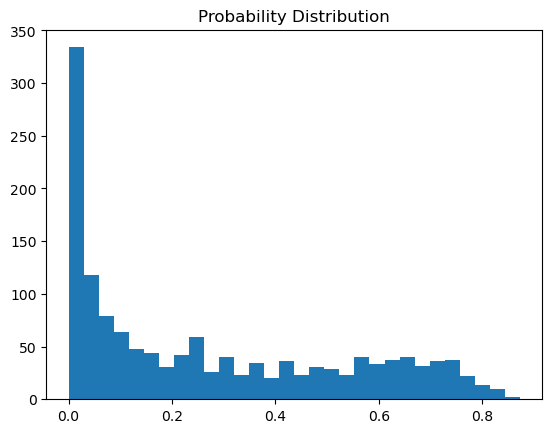

In [26]:
import matplotlib.pyplot as plt

plt.hist(x=y_prob, bins=30)
plt.title("Probability Distribution")

### Baseline Model: Logistic Regression

- ROC-AUC: 0.8430548581308789
- Recall (Churn): 0.60  
- Precision: 0.64 

- Observation:
    - Model is biased but it is within it's natural limits as dataset is imbalanced. Though FN is 146 which is not much higher FP which is 126 so model is balanced.

## Random Forest Model

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=
    [
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

rf_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [28]:
y_pred = rf_model.predict(x_test)
y_prob = rf_model.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC: ",roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC:  0.825915898349131
[[926 107]
 [181 193]]


In [29]:
y_pred = rf_model.predict(x_train)
y_prob = rf_model.predict_proba(x_train)[:, 1]

print("ROC-AUC: ",roc_auc_score(y_train, y_prob))

ROC-AUC:  0.9999510879687741


### Random Forest Model

- ROC-AUC: 0.825915898349131
- Recall (Churn): 0.52
- Precision: 0.64

- Observation:
    - Model is overfitting to training data as we can see it ROC-AUC score on training set is 0.999.

## XGBoost Model

In [30]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
        ))
    ]
)

xgb_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [31]:
y_pred = xgb_model.predict(x_test)
y_prob = xgb_model.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC: ",roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407

ROC-AUC:  0.8434845292512851
[[909 124]
 [165 209]]


In [32]:
y_pred = xgb_model.predict(x_train)
y_prob = xgb_model.predict_proba(x_train)[:, 1]

print(classification_report(y_train, y_pred))
print("ROC-AUC: ",roc_auc_score(y_train, y_prob))
print(confusion_matrix(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89      4130
           1       0.74      0.62      0.68      1495

    accuracy                           0.84      5625
   macro avg       0.80      0.77      0.79      5625
weighted avg       0.84      0.84      0.84      5625

ROC-AUC:  0.9050019840145118
[[3800  330]
 [ 563  932]]


In [33]:
np.std([0.8434845292512851, 0.9050019840145118])

np.float64(0.030758727381613338)

### XGBoost Model

- ROC-AUC: 0.8434845292512851
- Recall (Churn): 0.56
- Precision: 0.63

- Observation:
    - Model is not overfiting because standard deviation of test and train ROC-AUC is 0.03075 which is acceptable.

## Model Comparison

Model                | Precision | Recall | F1     | ROC-AUC
---------------------|-----------|--------|--------|---------------------
Logistic Regression  | 0.64      | 0.60   | 0.62   | 0.8430548581308789
Random Forest        | 0.64      | 0.52   | 0.57   | 0.825915898349131
XGBoost              | 0.63      | 0.56   | 0.59   | 0.8434845292512851

- Logistic Regression is the best choice for now because roc-auc is almost equal to XGBoost and difference is just noise but recall of churn class which matters most for out business is highest among others. 

## Threshold Optimization

In [34]:
from copy import deepcopy

log_reg_model = deepcopy(baseline_model)

y_pred = log_reg_model.predict(x_test)
y_prob = log_reg_model.predict_proba(x_test)[:, 1]

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)



In [35]:
precision[1], recall[1], thresholds[1]

(np.float64(0.26600284495021337),
 np.float64(1.0),
 np.float64(0.0005433803234951539))

In [36]:
precision, recall, thresholds

(array([0.26581379, 0.26600284, 0.26619217, ..., 1.        , 1.        ,
        1.        ], shape=(1405,)),
 array([1.        , 1.        , 1.        , ..., 0.00534759, 0.0026738 ,
        0.        ], shape=(1405,)),
 array([5.39930587e-04, 5.43380323e-04, 5.47127954e-04, ...,
        8.38740210e-01, 8.51071798e-01, 8.72827459e-01], shape=(1404,)))

Text(0.5, 1.0, 'Customer Churn Prediction')

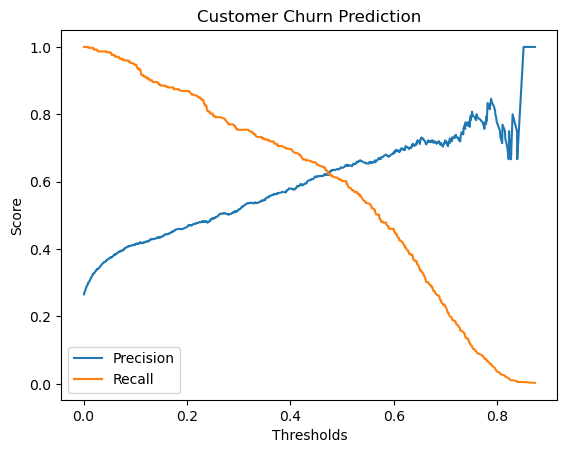

In [37]:
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Thresholds")
plt.ylabel("Score")
plt.legend()
plt.title("Customer Churn Prediction")

### F1 Score Selection

In [38]:
f1_score = 2 * ((precision * recall) / (precision + recall + + 1e-6))
best_index = f1_score.argmax()

best_thresholds = thresholds[best_index]
best_thresholds

np.float64(0.4471661915255089)

### Evaluation of best threshold according to f1_score

In [39]:

y_pred_out = (y_prob > best_thresholds).astype(int)

print("Thresholds : 0.5\n",classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)
print("Thresholds : 0.4471661915255089\n",classification_report(y_test, y_pred_out))
confusion_matrix(y_test, y_pred_out)

Thresholds : 0.5
               precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Thresholds : 0.4471661915255089
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      1033
           1       0.61      0.66      0.63       374

    accuracy                           0.80      1407
   macro avg       0.74      0.75      0.75      1407
weighted avg       0.80      0.80      0.80      1407



array([[879, 154],
       [129, 245]])

- Though we are using best threshold according to f1_score which is balanced in both ways recall and precision but in our business use correct prediction of churn is very important so we will find business oriented threshold.

## Business-Oriented Threshold

- We need to correctly identify churn which needs high recall so we will try to increase recall by decreasing threshold. 

In [40]:
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0, best_thresholds, 0.1)

for threshold in thresholds:
    
    print(f"Threshold : {threshold} Recall : {recall_score(y_test, (y_prob > threshold).astype(int))} Precision : {precision_score(y_test, (y_prob > threshold).astype(int))}")


Threshold : 0.0 Recall : 1.0 Precision : 0.2658137882018479
Threshold : 0.1 Recall : 0.946524064171123 Precision : 0.41500586166471276
Threshold : 0.2 Recall : 0.8689839572192514 Precision : 0.46628407460545196
Threshold : 0.30000000000000004 Recall : 0.7540106951871658 Precision : 0.5183823529411765
Threshold : 0.4 Recall : 0.6951871657754011 Precision : 0.579064587973274


In [41]:
bo_threshold = 0.3

y_pred = (y_prob > bo_threshold).astype(int)

print("Thresholds : 0.3\n",classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

Thresholds : 0.3
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



array([[771, 262],
       [ 92, 282]])

- This reduces chances of missing a churn while maintaining precision. which is best case for our business.

## Error Analysis

In [42]:
import shap

x_train_trans = log_reg_model.named_steps["preprocessing"].transform(x_train)
x_test_trans = log_reg_model.named_steps["preprocessing"].transform(x_test)

feature_names = log_reg_model.named_steps["preprocessing"].get_feature_names_out()

explainer = shap.LinearExplainer(log_reg_model.named_steps["model"] , masker=x_train_trans)

shap_values = explainer.shap_values(x_test_trans)

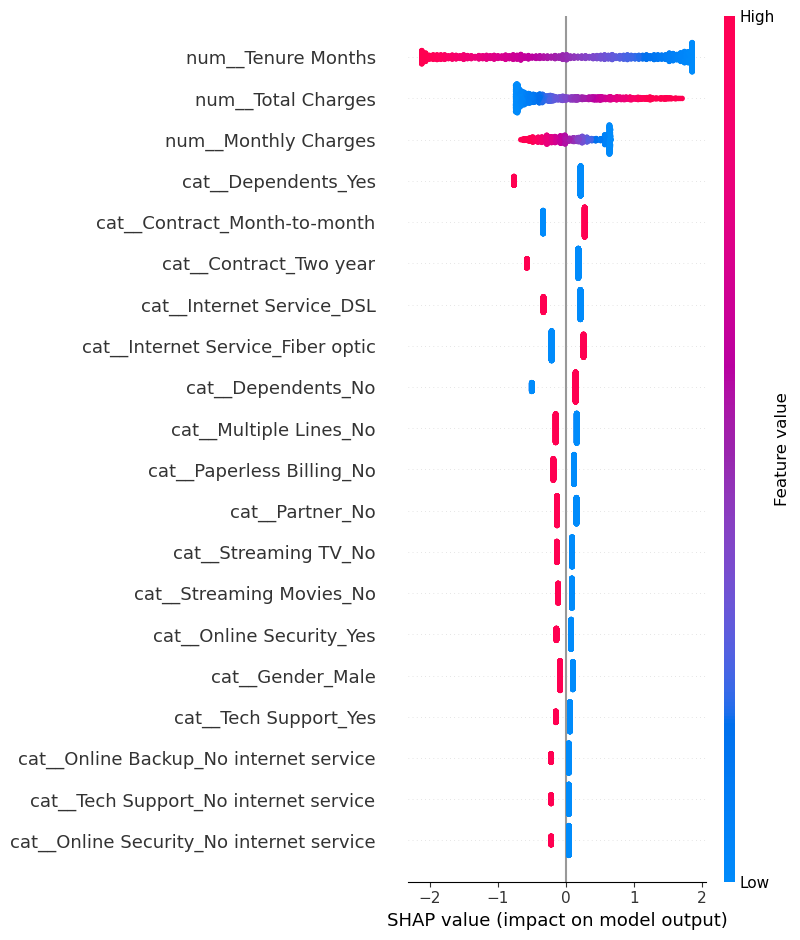

In [43]:
shap.summary_plot(shap_values, x_test_trans, feature_names)

In [44]:
result = x_test.copy()

result["true"] = y_test
result["pred"] = y_pred
result["prob"] = y_prob

false_neg = result[(result["true"] == 1) & (result["pred"] == 0)]
false_pos = result[(result["true"] == 0) & (result["pred"] == 1)]
true_neg = result[(result["true"] == 0) & (result["pred"] == 0)]
true_pos = result[(result["true"] == 1) & (result["pred"] == 1)]

In [45]:
false_neg.shape, false_pos.shape, true_neg.shape, true_pos.shape

((92, 22), (262, 22), (771, 22), (282, 22))

### False Negative

In [46]:
true_neg.describe()

,Tenure Months,Monthly Charges,Total Charges,true,pred,prob
count,771.000000,771.000000,771.000000,771.0,771.0,771.000000
mean,43.568093,56.076719,2780.326524,0.0,0.0,0.079235
std,22.745206,32.173992,2371.159062,0.0,0.0,0.085212
min,1.000000,18.250000,19.200000,0.0,0.0,0.000540
25%,24.000000,20.625000,740.775000,0.0,0.0,0.012119
50%,48.000000,55.000000,1872.200000,0.0,0.0,0.041877
75%,65.000000,84.475000,4545.700000,0.0,0.0,0.127305
max,72.000000,118.750000,8672.450000,0.0,0.0,0.299550


In [47]:
false_neg.describe()

,Tenure Months,Monthly Charges,Total Charges,true,pred,prob
count,92.000000,92.000000,92.000000,92.0,92.0,92.000000
mean,27.989130,61.055435,2251.990761,1.0,0.0,0.169862
std,23.872599,30.753291,2339.308664,0.0,0.0,0.082590
min,1.000000,18.850000,18.850000,1.0,0.0,0.008414
25%,4.000000,28.487500,133.487500,1.0,0.0,0.103805
50%,28.500000,60.125000,1552.775000,1.0,0.0,0.173937
75%,48.250000,85.137500,3913.000000,1.0,0.0,0.238251
max,68.000000,113.150000,7856.000000,1.0,0.0,0.296571


In [48]:
result[result["true"] == 1].describe()

,Tenure Months,Monthly Charges,Total Charges,true,pred,prob
count,374.000000,374.000000,374.000000,374.0,374.000000,374.000000
mean,17.029412,73.488904,1446.750000,1.0,0.754011,0.505645
std,18.713637,24.240153,1799.019137,0.0,0.431249,0.226594
min,1.000000,18.850000,18.850000,1.0,0.000000,0.008414
25%,2.000000,59.275000,118.400000,1.0,1.000000,0.320901
50%,9.000000,76.650000,607.525000,1.0,1.000000,0.571202
75%,27.000000,90.487500,2235.650000,1.0,1.000000,0.688954
max,69.000000,113.200000,7856.000000,1.0,1.000000,0.872827


- Model's prediction depends heavily on `Tenure Months` but in false negative instances this feature is not extreme because model is accurately predicting when this feature is hight and when it is low.

### False Positive

In [49]:
true_pos.describe()

,Tenure Months,Monthly Charges,Total Charges,true,pred,prob
count,282.000000,282.000000,282.000000,282.0,282.0,282.000000
mean,13.453901,77.545213,1184.047340,1.0,1.0,0.615191
std,15.104370,20.163239,1497.450377,0.0,0.0,0.130340
min,1.000000,21.000000,21.000000,1.0,1.0,0.318750
25%,2.000000,70.062500,118.400000,1.0,1.0,0.529937
50%,7.000000,79.850000,489.150000,1.0,1.0,0.636743
75%,20.000000,90.812500,1738.112500,1.0,1.0,0.712976
max,69.000000,113.200000,7007.600000,1.0,1.0,0.872827


In [50]:
false_pos.describe()

,Tenure Months,Monthly Charges,Total Charges,true,pred,prob
count,262.000000,262.000000,262.00000,262.0,262.0,262.000000
mean,18.576336,73.739885,1616.81355,0.0,1.0,0.509718
std,18.019144,23.290525,1854.24890,0.0,0.0,0.140724
min,1.000000,19.750000,19.75000,0.0,1.0,0.302129
25%,4.000000,55.475000,257.97500,0.0,1.0,0.391712
50%,12.000000,75.600000,743.52500,0.0,1.0,0.487515
75%,28.750000,91.125000,2391.08750,0.0,1.0,0.621436
max,68.000000,116.500000,7320.90000,0.0,1.0,0.838740


In [51]:
result[result["true"] == 0].describe()

,Tenure Months,Monthly Charges,Total Charges,true,pred,prob
count,1033.000000,1033.000000,1033.000000,1033.0,1033.000000,1033.000000
mean,37.229429,60.556631,2485.224492,0.0,0.253630,0.188419
std,24.217134,31.123434,2306.745982,0.0,0.435299,0.213402
min,1.000000,18.250000,19.200000,0.0,0.000000,0.000540
25%,14.000000,24.950000,527.350000,0.0,0.000000,0.018010
50%,39.000000,63.300000,1596.600000,0.0,0.000000,0.088684
75%,60.000000,88.850000,4245.550000,0.0,1.000000,0.304102
max,72.000000,118.750000,8672.450000,0.0,1.000000,0.838740


- False Positive instance are edge cases they are falsely identified due to low `Tenure Months` and high `Monthly Charges`. 

## Final Model

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression())
    ]
)

log_reg_model.fit(x_train, y_train)

y_prob = log_reg_model.predict_proba(x_test)[:, 1]
y_pred = (y_prob > 0.3).astype(int)

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("ROC-AUC : ", roc_auc_score(y_test,y_prob))
print("Confusion Matrix : \n", confusion_matrix(y_test, y_pred))

Accuracy :  0.7484008528784648
Precision :  0.5183823529411765
Recall :  0.7540106951871658
ROC-AUC :  0.8430548581308789
Confusion Matrix : 
 [[771 262]
 [ 92 282]]
